In [15]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import find_peaks

# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = np.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (np.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * np.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = np.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength)))
    return amplitude, phase

def gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_1, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho_1 (float): a precalculated rho value
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**-(rho_1**2/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho_1 ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength))))
    return amplitude, phase

def fwhm(x,y):
    """
    Finds the full width at half maximum of the graph
    Args:
        x (np.array): x coord
        y (np.array): y coord
    Returns:
        fw_hm (float): full width at half maximum
    """
    # Target y-value
    target_y = np.max(y)/2
    
    # Find indices where y crosses target_y
    # This detects sign changes in (y - target_y)
    indices = np.where(np.diff(np.sign(y - target_y)) != 0)[0]
    
    # Interpolate to find more accurate x-values
    x_at_target = []
    for i in indices:
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        # Linear interpolation formula
        x_cross = x0 + (target_y - y0) * (x1 - x0) / (y1 - y0)
        x_at_target.append(x_cross)
    fw_hm = np.sum(abs(np.array(x_at_target)))
    return float(fw_hm)

def calculate_2dft(input):
    """
    Calculates the 2D Fast Fourier Transform of an image
    Args:
        input (nested np.array): the nested array of values that come out of the gaussian_beam function
    Returns:
        np.fft.ifftshift(ft_1) (nested np.array): the fourier transformed arrays
    """
    ft = np.fft.ifftshift(input) # shifts the input
    ft_1 = np.fft.fft2(ft) # performs 2D fft
    return np.fft.fftshift(ft_1) # inverse shifts

def pinhole(x, y, radius, amp):
    """
    Sets up a pinhole for the purposes of a gaussian beam
    Args:
        x (np.meshgrid): a meshgrid of x
        y (np.meshgrid): a meshgrid of y
        radius (float): the radius of the pinhole
        amp (np.meshgrid): the amplitude values
    Returns:
        amp (np.meshgrid): the updated amplitude values
    """

    # somehow this works fairly well
    # iterates through the mesh grid and identifies locations outside of the radius defined
    
    a = 0
    b = 0

    while a < len(x):
        if x[a,b]**2 + y[a,b]**2 >= radius**2:
            amp[a,b] = 0
        b += 1
        if len(x) == b:
            b = 0
            a += 1
    return amp

def pinhole_slit(x, y, radius, wavelength, amp):
    """
    Sets up a pinhole with a slit inside it for the purposes of a gaussian beam
    Args:
        x (np.meshgrid): a meshgrid of x
        y (np.meshgrid): a meshgrid of y
        radius (float): the radius of the pinhole
        wavelength (float): the wavelength of the beam, used to be the slit width
        amp (np.meshgrid): the amplitude values
    Returns:
        amp (np.meshgrid): the updated amplitude values
    """
    
    # somehow this works fairly well
    # iterates through the mesh grid and identifies locations outside of the radius defined
    wavelength = wavelength * (10**-9)
    a = 0
    b = 0

    while a < len(x):
        if x[a,b]**2 + y[a,b]**2 >= radius**2 or abs(x[a,b]) > wavelength/2 or abs(y[a,b]) > wavelength:
            amp[a,b] = 0
        b += 1
        if len(x) == b:
            b = 0
            a += 1
    return amp

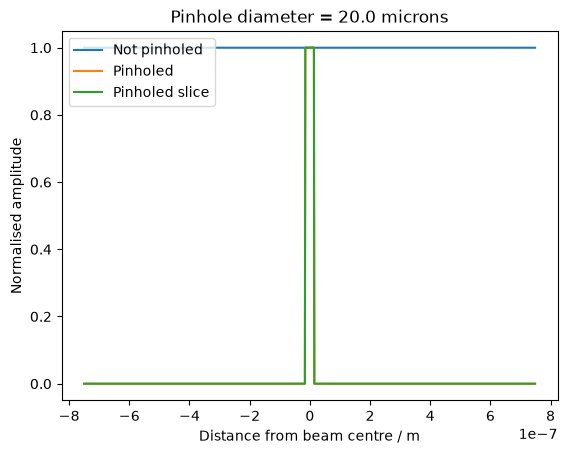

In [31]:
# sets initial parameters of the beam

wavelength = 29
omega_0 = 7.5e-5
z = 1e-10 # at the source
a_0 = 100
n = 1
variable = omega_0 / 100 # window size as a linear function of omega_0
samples = 1000
pinhole_radius = 1e-5


# defines a meshgrid of xy values and calculates the beam at this point

initial_beam_x = np.linspace(-variable,variable,samples)
initial_beam_y = np.linspace(-variable,variable,samples)
x_mesh, y_mesh = np.meshgrid(initial_beam_x, initial_beam_y)
amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, x_mesh, y_mesh, n)

marginal = np.sum(amp, 0)
plt.plot(np.linspace(-variable,variable,samples, endpoint = False), marginal/np.max(marginal), '-', label = ('Not pinholed'))

amp = pinhole_slit(x_mesh, y_mesh, pinhole_radius, wavelength, amp)
    
marginal = np.sum(amp, 0)
plt.plot(np.linspace(-variable,variable,samples, endpoint = False), marginal/np.max(marginal), '-', label = ('Pinholed'))
# not the best representation, but shows the sharp cut off. In reality, this is far less curved

slice_2d = amp[len(y_mesh)//2, :]
plt.plot(np.linspace(-variable,variable,samples, endpoint = False), slice_2d/np.max(slice_2d), '-', label = 'Pinholed slice')
# better representation of the graph

plt.legend(fontsize = 10, loc = 2)
plt.title(f'Pinhole diameter = {2 * pinhole_radius * (10**6)} microns')
plt.xlabel('Distance from beam centre / m')
plt.ylabel('Normalised amplitude')
plt.show()

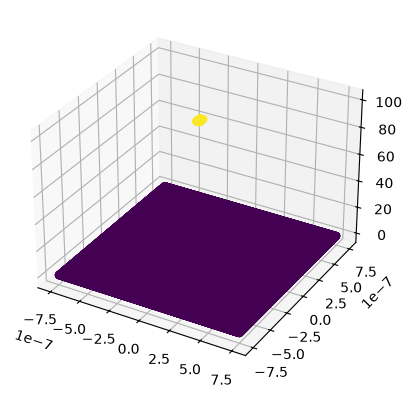

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_mesh, y_mesh, abs(amp), c=amp, marker='o', s=20)
plt.show()

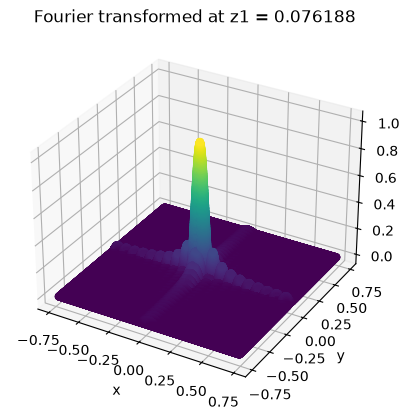

In [32]:
# does the 2D fourier transform and normalises the values
ft = calculate_2dft(amp)
ft_norm = abs(ft)/np.max(abs(ft))

z1=0.076188 # defining a length far beyond the Fraunhofer condition for the parameters set

# defines a new meshgrid of xy coordinates to enable plotting in 3D, including the corrections needed for Fraunhofer diffraction

dx = initial_beam_x[1]-initial_beam_x[0]
x_post_fft = np.fft.fftshift(np.fft.fftfreq(len(ft), d=dx))
x_post_fft_corr = x_post_fft*wavelength*1e-9*z1
 
dy = initial_beam_x[1]-initial_beam_x[0]
y_post_fft = np.fft.fftshift(np.fft.fftfreq(len(ft), d=dx))
y_post_fft_corr = y_post_fft*wavelength*1e-9*z1

x_mesh_fft, y_mesh_fft = np.meshgrid(x_post_fft_corr,y_post_fft_corr)

#plots the fft of the source ideal beam
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_mesh_fft, y_mesh_fft, abs(ft_norm), c=ft_norm, marker='o', s=20)
plt.title(f'Fourier transformed at z1 = {z1}')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

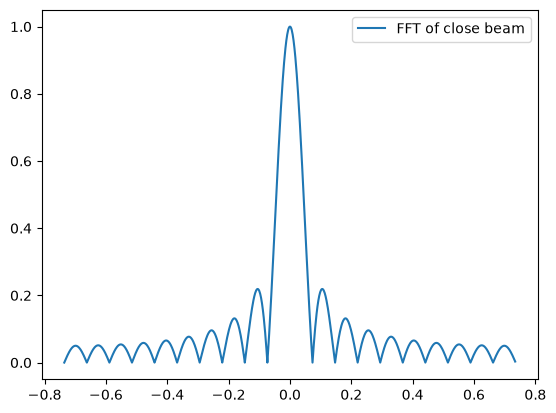

In [33]:
marginal_fft = np.sum(abs(ft_norm), 0)
plt.plot(x_post_fft_corr ,marginal_fft/np.max(marginal_fft), '-', label = 'FFT of close beam')
plt.legend()

plt.show()

In [34]:
maxima = list(find_peaks(marginal_fft/np.max(marginal_fft)))
maxima = list(maxima[0])
maxima = [int(x) for x in maxima]

maxima_pos = []
for items in maxima:
    maxima_pos.append(float(x_post_fft_corr[items]))

hypotenuses = [math.sqrt((x**2) + (z1**2)) for x in maxima_pos]

sin_theta = [abs(a) / b for a,b in zip(maxima_pos, hypotenuses)]

a_sin_theta = [a * wavelength for a in sin_theta]
round(max(a_sin_theta))

29